# 1.4.2 设计可以区分解释的实验

## 学习目标与先修知识

- 设计能区分候选模型（model）的计算实验（computational experiment）。
- 保持条件可比，并在观察前记录预测。
- 解释符合、冲突与证据不足三种结果。

**先修知识**：[规则、参数与初值](01-规则参数与初值.ipynb)；绝对值与大小比较。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

固定移除 1 U/段和比例移除 10%/段在 10 U 起点的第一段都预测 9 U。如果只能增加一次观察，你会继续观察第二段，还是另选一个起点？

先比较候选起点 10、20、30 U 的第一段预测。这里“预测差超过 0.5 U”只是一条教学选择门槛，不是统计显著性结论。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
initials = [10,20,30]
fixed_ends = [a-1 for a in initials]
fraction_ends = [a*(1-.1) for a in initials]
display(Markdown(show_table(['起点 / U','固定量预测 / U','比例预测 / U','预测差 / U'],
    [(a,x,y,abs(x-y)) for a,x,y in zip(initials,fixed_ends,fraction_ends)])))

| 起点 / U | 固定量预测 / U | 比例预测 / U | 预测差 / U |
| --- | --- | --- | --- |
| 10 | 9 | 9 | 0 |
| 20 | 19 | 18 | 1 |
| 30 | 29 | 27 | 2 |

## 模型假设

我们把两个候选的参数（parameter）固定为 c=1、r=0.1，只允许选择初值（initial condition）。各实验使用相同段长、外部输入（input）、测量方法和终点时刻。先记录预测，再读取核对值。

先用无随机误差的核对值比较两套预测。选择门槛衡量预测是否分得足够开；有测量误差时，还需把这个间距与测量精度一起考虑。

## 数学解释与推导

对于候选起点 A，两组第一段预测为 A−c 和 A(1−r)，两者间距为

$$D=|(A-c)-A(1-r)|=|rA-c|.$$

当 c=1、r=0.1 时，A=10 给 D=0；A=20 给 D=1。差异为零的条件无法凭这一观测（observation）区分候选，差异非零则提供机会。机会能否变成证据，还取决于测量误差和其他条件是否受控。

数组（array）或循环只帮我们列出预测，不负责替我们决定观测可信度。下面用两条等价算式核对这个间距。

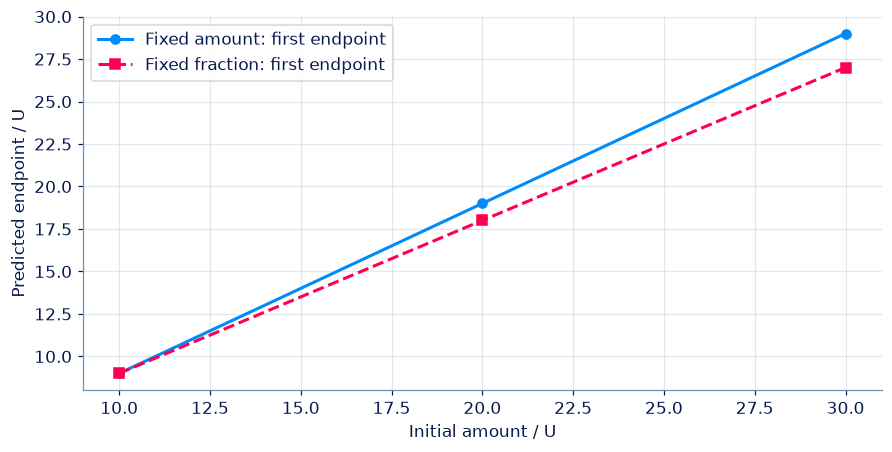

In [2]:
def separating_initials(initials, fixed, fraction, threshold):
    return [i for i,a in enumerate(initials) if abs(fraction*a-fixed)>threshold]

selected = separating_initials(initials,1,.1,.5)
assert selected == [1,2]
for a,x,y in zip(initials,fixed_ends,fraction_ends):
    assert abs(abs(x-y)-abs(.1*a-1)) < 1e-12
fig, ax = plt.subplots()
ax.plot(initials,fixed_ends,'o-',label='Fixed amount: first endpoint')
ax.plot(initials,fraction_ends,'s--',label='Fixed fraction: first endpoint')
ax.set(xlabel='Initial amount / U',ylabel='Predicted endpoint / U')
ax.legend()
plt.show()

## 对照实验

起点固定为 20 U，事前预测为 19 与 18 U。分别考虑人工核对值 19、18、17 U。如果都不符合，应报告冲突，而不是选更接近的一个就宣布它正确。

In [3]:
predictions = {'固定量':19.0, '固定比例':18.0}
rows=[]
for observed in [19.0,18.0,17.0]:
    matches=[name for name,value in predictions.items() if abs(observed-value)<1e-12]
    rows.append([observed,'、'.join(matches) if matches else '两者均不符合'])
display(Markdown(show_table(['人工核对值 / U','在这组条件下符合的候选'],rows)))
assert separating_initials([2,4,6],1,.5,1) == [2]

| 人工核对值 / U | 在这组条件下符合的候选 |
| --- | --- |
| 19 | 固定量 |
| 18 | 固定比例 |
| 17 | 两者均不符合 |

## 结果解释

核对值 18 U 与比例候选相符，只能说在这组条件下没有冲突；不意味着排除了所有其他机制。17 U 则反驳这里固定的两个候选，需要检查遗漏过程、测量关系或新的结构。

用当前数据重新估参后，我们得到一个更新模型。保留原预测及其检验结果，再用未参与拟合的数据检查新预测；这些数据可以来自预留观测，也可以来自新的实验条件。

[本章导览与各节入口](http://127.0.0.1:8000/chapters/01-04-模型假设与计算实验/)

## 回看导论的传播实验

[六人传播实验](../../00-导论/03-从系统问题走向计算与证据.ipynb)固定了人数、联系数和传递规则，比较不同连接方式，又改变起点核对解释。现在可以用本篇的语言重读它：哪些条件保持不变，哪一项被改变，观察到的差异支持什么结论？把“每轮只由上一轮已收到者发送”改成即时继续传递，就改变了规则；换起点则改变了初始条件。先把这些区别说清楚，再用独立预测与观测选择解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：选择能区分解释的实验

已知固定移除 1 U/段和比例移除 10%/段在初值（initial condition） 10 U 的第一段预测相同。要比较模型（model），哪项设计最合适？

- **A.** 改初值为 20 U，保持段长、输入（input）、测量方法与两组原参数（parameter）相同，比较第一段末。
- **B.** 同时把比例改成 5%，并改变段长。
- **C.** 只记录两组起点，不记录之后。
- **D.** 先看结果，再随意修改两组参数直到一致。

[作答：选择能区分解释的实验](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-distinguish-design)

### 第 2 题 · Python 计算题：找出预测分离的初值

候选初值（initial condition）列表中，每段固定移除 fixed U 或移除当前量的 fraction。寻找两组第一段末预测差的绝对值严格大于 threshold 的候选，返回其从 0 开始的索引。

**函数与代码模板**

```python
def solve(
    initials: list[float],
    fixed: float,
    fraction: float,
    threshold: float,
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initials` | `list[float]` | 候选起点所追踪物质总量（tracked amount），保留原顺序。 | U |
| `fixed` | `float` | 每段固定移除量。 | U/段 |
| `fraction` | `float` | 比例移除系数。 | 无量纲 |
| `threshold` | `float` | 希望预测差超过的数值门槛。 | U |

**返回值**

直接返回 indices（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `indices` | `list[int]` | 满足严格大于条件的候选索引，按原顺序。 | 索引 |

**计算规则**

第一段末分别为 A−fixed 和 A×(1−fraction)。差可等价写成 abs(fraction×A−fixed)。仅将严格大于 threshold 的索引加入结果。门槛是本题实验选择条件，不是统计显著性。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ len(initials) ≤ 1000；0 ≤ fixed ≤ A ≤ 1000。
- 0 ≤ fraction ≤ 1；0 ≤ threshold ≤ 1000。
- 测试中预测差距门槛至少 1e−6，或恰好相等且能被二进制精确表示。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initials | 候选起点所追踪物质总量（tracked amount），保留原顺序。 | [10, 20, 30] | U |
| fixed | 每段固定移除量。 | 1 | U/段 |
| fraction | 比例移除系数。 | 0.1 | 无量纲 |
| threshold | 希望预测差超过的数值门槛。 | 0.5 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initials = [10, 20, 30]
fixed = 1
fraction = 0.1
threshold = 0.5

result = solve(initials, fixed, fraction, threshold)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| indices | 满足严格大于条件的候选索引，按原顺序。 | [1, 2] | 索引 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1, 2]
```

**样例解释**

三组第一段末预测差为 0、1、2 U；只有索引 1、2 严格超过 0.5 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：找出预测分离的初值](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-separation)

### 第 3 题 · 多项选择题：先写下可能的反例

一个计算实验（computational experiment）准备比较两种清除规则。以下哪些做法支持可检验的解释？

- **A.** 运行前记录两种规则的参数（parameter）、预测和不能支持它们的结果。
- **B.** 看到观测（observation）后悄悄改变原先声称固定的系数。
- **C.** 把独立条件留作核对，并写明误差和未纳入的过程。
- **D.** 只要一条曲线看起来更平滑，就确定它是真实机制。

[作答：先写下可能的反例](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-prediction-record)

### 第 4 题 · 单项选择题：观测落在两个预测之外

在初值（initial condition） 20 U 的一段实验中，两种固定候选模型（model）预测为 19 与 18 U。按题设观测（observation）准确为 17 U，且条件记录无误。最恰当的结论是什么？

- **A.** 选 18 U 那个并宣称它完全正确。
- **B.** 17 比 18 小，所以所追踪物质总量（tracked amount）不可能守恒。
- **C.** 两个固定候选在这组条件下都不符合观测，应检查遗漏机制或提出新假设。
- **D.** 把观测改写成 18 U。

[作答：观测落在两个预测之外](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-falsification)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。